# 03 — Analytical Fourier Series vs FFT

- `compare_fourier_vs_fft` returns both reconstructions; 
- here we visualize and quantify the agreement.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from src.signal_processing import compare_fourier_vs_fft

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=150):
    """Save a figure to figures/<name>.png and return the path."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved → {path.relative_to(PROJECT_ROOT)}")
    return path

In [14]:
def smooth(x):
    return np.cos(x) + 0.3 * np.cos(3 * x) - 0.5 * np.sin(2 * x)

out = compare_fourier_vs_fft(smooth, L=np.pi, n_samples=1024, n_modes=16)

saved → figures\03_fourier_vs_fft.png


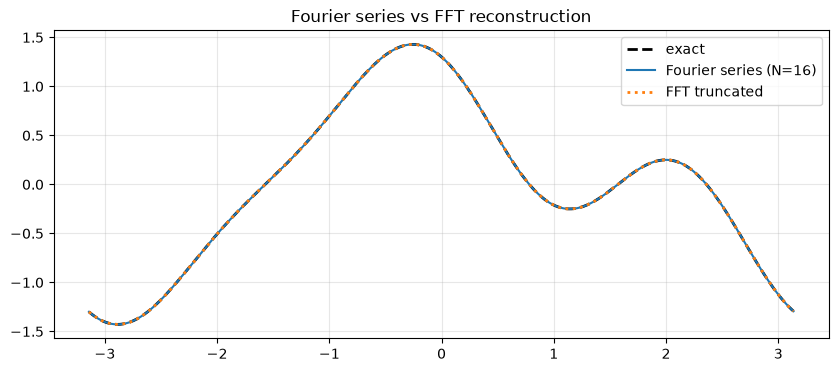

Max |Fourier - FFT| = 3.220e-15


In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(out["x"], out["exact"], "k--", lw=2, label="exact")
ax.plot(out["x"], out["fourier_series"], label="Fourier series (N=16)")
ax.plot(out["x"], out["fft_reconstruction"], ":", lw=2, label="FFT truncated")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Fourier series vs FFT reconstruction")
save_fig(fig, "03_fourier_vs_fft")
plt.show()

err = np.max(np.abs(out["fourier_series"] - out["fft_reconstruction"]))
print(f"Max |Fourier - FFT| = {err:.3e}")

saved → figures\03_fft_spectrum.png


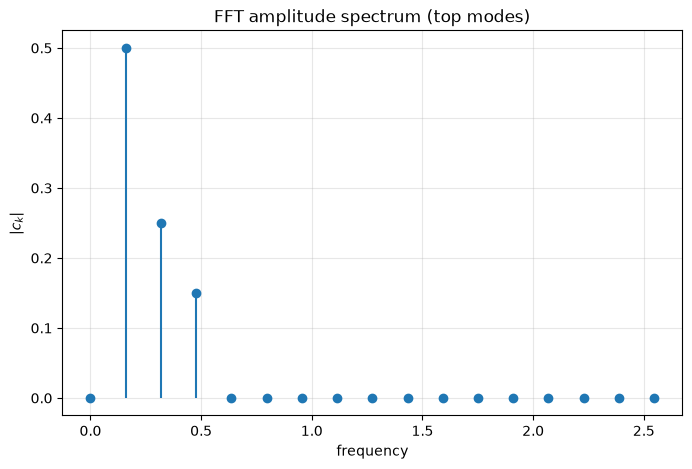

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.stem(out["freqs"], out["fft_amplitudes"], basefmt=" ")
ax.set_xlabel("frequency")
ax.set_ylabel(r"$|c_k|$")
ax.set_title("FFT amplitude spectrum (top modes)")
ax.grid(alpha=0.3)
save_fig(fig, "03_fft_spectrum")
plt.show()

saved → figures\03_aliasing_square_wave.png


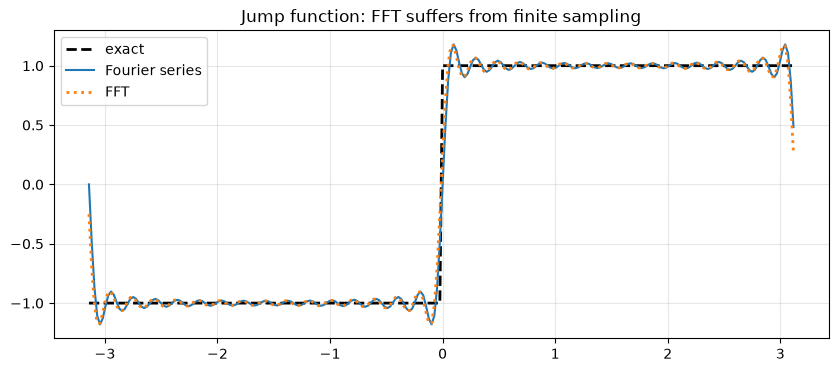

In [17]:
from src.gibbs_analysis import square_wave
out2 = compare_fourier_vs_fft(square_wave, L=np.pi, n_samples=256, n_modes=32)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(out2["x"], out2["exact"], "k--", lw=2, label="exact")
ax.plot(out2["x"], out2["fourier_series"], label="Fourier series")
ax.plot(out2["x"], out2["fft_reconstruction"], ":", lw=2, label="FFT")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Jump function: FFT suffers from finite sampling")
save_fig(fig, "03_aliasing_square_wave")
plt.show()

saved → figures\03_aliasing_convergence.png


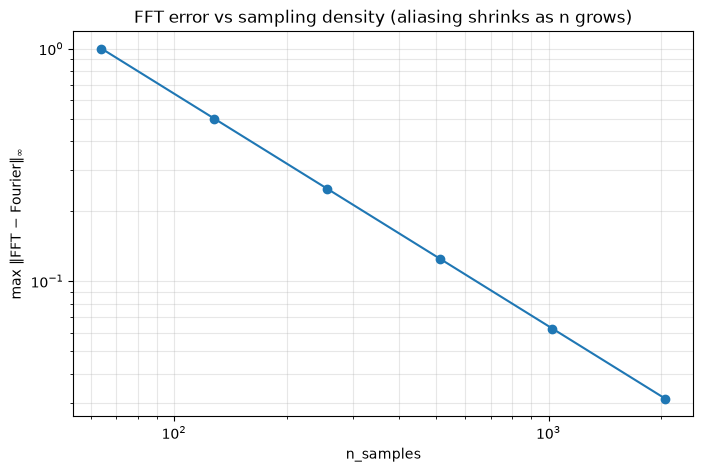

In [18]:
sample_counts = [64, 128, 256, 512, 1024, 2048]
max_diffs = []
for n in sample_counts:
    o = compare_fourier_vs_fft(square_wave, L=np.pi, n_samples=n, n_modes=32)
    max_diffs.append(np.max(np.abs(o["fft_reconstruction"] - o["fourier_series"])))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(sample_counts, max_diffs, "o-")
ax.set_xlabel("n_samples"); ax.set_ylabel(r"max $\|$FFT $-$ Fourier$\|_\infty$")
ax.set_title("FFT error vs sampling density (aliasing shrinks as n grows)")
ax.grid(which="both", alpha=0.3)
save_fig(fig, "03_aliasing_convergence")
plt.show()